<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/30_Experimental_Design_in_Python/01_Experimental_Design_Preliminaries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro
from scipy.stats import anderson

In [26]:

import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/chick_weight.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
weights = pd.read_csv(url)
display(weights.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/chick_weight.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
chicken_data = pd.read_csv(url)
display(chicken_data.head())



,weight,Time,Chick,Diet
0,42,0,1,1
1,51,2,1,1
2,59,4,1,1
3,64,6,1,1
4,76,8,1,1


,weight,Time,Chick,Diet
0,42,0,1,1
1,51,2,1,1
2,59,4,1,1
3,64,6,1,1
4,76,8,1,1


**Non-random assignment of subjects**  
An agricultural firm is conducting an experiment to measure how feeding sheep different types of grass affects their weight. They have asked for your help to properly set up the experiment. One of their managers has said you can perform the subject assignment by taking the top 250 rows from the DataFrame and that should be fine.

Your task is to use your analytical skills to demonstrate why this might not be a good idea. Assign the subjects to two groups using non-random assignment (the first 250 rows) and observe the differences in descriptive statistics.

You have received the DataFrame, weights which has a column containing the weight of the sheep and a unique id column.

numpy and pandas have been imported as np and pd, respectively.

In [4]:
# Non-random assignment
group1_non_rand = weights.iloc[0:250,:]
group2_non_rand = weights.iloc[250:,:]

# Compare descriptive statistics of groups
compare_df_non_rand = pd.concat([group1_non_rand['weight'].describe(), group2_non_rand['weight'].describe()], axis=1)
compare_df_non_rand.columns = ['group1', 'group2']

# Print to assess
print(compare_df_non_rand)

# Those two datasets have a much greater difference in means. It may be that the
# dataset was sorted before you received it. Presenting these results to the firm
# will help them understand best-practice group assignment. Hopefully you can now
# work with them to set up the experiment properly.

           group1      group2
count  250.000000  328.000000
mean   105.876000  133.969512
std     61.548791   75.405361
min     35.000000   39.000000
25%     58.250000   68.000000
50%     89.000000  123.000000
75%    138.750000  184.000000
max    331.000000  373.000000


### Random assignment of subjects
Having built trust from your last work with the agricultural firm, you have been given the task of properly setting up the experiment.

Use your knowledge of best practice experimental design set up to assign the sheep to two even groups of 250 each.

The weights DataFrame is available for you to use. Additionally, numpy and pandas have been imported as np and pd respectively.

In [10]:
# Randomly assign half
group1_random = weights.sample(frac=0.5, random_state=42, replace=False)

# Create second assignment
group2_random = weights.sample(group1_random.drop())

# Compare assignments
compare_df_random = pd.concat([group1_random['weight'].describe(), group2_random['weight'].descibe()], axis=1)
compare_df_random.columns = ['group1', 'group2']
print(compare_df_random)

ValueError: Need to specify at least one of 'labels', 'index' or 'columns'

In [12]:
# Randomly assign half
group1_random = weights.sample(frac=0.5, random_state=42, replace=False)

# Create second assignment
group2_random = weights.drop(group1_random.index)

# Compare assignments
compare_df_random = pd.concat([group1_random['weight'].describe(), group2_random['weight'].describe()], axis=1)
compare_df_random.columns = ['group1', 'group2']
print(compare_df_random)

# While there are some differences in these datasets, you can clearly see the mean
# of the two sets are very close. This best-practice setup will ensure the experiment
# is on the right path from the beginning. Let's continue building foundational
# experimental design skills by learning about experimental design setup.

           group1      group2
count  289.000000  289.000000
mean   120.044983  123.591696
std     70.089685   72.118725
min     35.000000   39.000000
25%     62.000000   63.000000
50%    105.000000  103.000000
75%    163.000000  164.000000
max    373.000000  361.000000


**Blocking experimental data**  
You are working with a manufacturing firm that wants to conduct some experiments on worker productivity. Their dataset only contains 100 rows, so it's important that experimental groups are balanced.

This sounds like a great opportunity to use your knowledge of blocking to assist them. They have provided a productivity_subjects DataFrame. Split the provided dataset into two even groups of 50 entries each.

The libraries numpy and pandas have been imported as np and pd respectively.

In [18]:
# Create a dummy productivity_subjects DataFrame for demonstration
# based on the description in the markdown cell.
data = {'productivity': np.random.rand(100)}
productivity_subjects = pd.DataFrame(data)
display(productivity_subjects.head())

,productivity
0,0.694558
1,0.838115
2,0.268949
3,0.318147
4,0.275459


In [19]:
# Randomly assign half
block_1 = productivity_subjects.sample(frac=0.5, random_state=42, replace=False)

# Set the block column
block_1['block'] = 1

# Create second assignment and label
block_2 = productivity_subjects.drop(block_1.index)
block_2['block'] = 2

# Concatenate and print
productivity_combined = pd.concat([block_1, block_2], axis=0)
print(productivity_combined['block'].value_counts())

# You were able to succesfully block this data into two equal sized groups. This
# is important especially when the size of the data is small, as is the case with
# this data. Let's consider an example where they may be a confounding variable and use stratification to assist.

block
1    50
2    50
Name: count, dtype: int64


   **Stratifying an experiment**   
You are working with a government organization that wants to undertake an experiment around how some particular government policies impact the net wealth of individuals in a number of areas.

They have approached you to help set up the experimental design. They have warned you that there is likely to be a small group of users who already have high net wealth and are concerned that this group might overshadow any experimental outcome observed. You know just what to do!

Use your knowledge of experimental design to undertake block randomization, stratifying by the high_wealth column in the provided wealth_data DataFrame. There are 2000 rows in the DataFrame with 200 high net wealth subjects (high_wealth is 1).

In [23]:
# Create a dummy wealth_data DataFrame for demonstration
# based on the description in the markdown cell.
data = {'high_wealth': [1] * 200 + [0] * 1800}
wealth_data = pd.DataFrame(data)
# Shuffle the DataFrame to avoid any unintended order effects
wealth_data = wealth_data.sample(frac=1, random_state=42).reset_index(drop=True)
display(wealth_data.head())

,high_wealth
0,0
1,0
2,0
3,0
4,0


In [24]:
# Create the first block
strata_1 = wealth_data[wealth_data['high_wealth'] == 1].copy()
strata_1['Block'] = 1

# Create two groups assigning to Treatment or Control
strata_1_g1 = strata_1.sample(100, replace=False)
strata_1_g1['T_C'] = 'T'
strata_1_g2 = strata_1.drop(strata_1_g1.index)
strata_1_g2['T_C'] = 'C'

# Create the second block and assign groups
strata_2 = wealth_data[wealth_data['high_wealth'] == 0].copy()
strata_2['Block'] = 2

strata_2_g1 = strata_2.sample(900, replace=False)
strata_2_g1['T_C'] = 'T'
strata_2_g2 = strata_2.drop(strata_2_g1.index)
strata_2_g2['T_C'] = 'C'

# Concatenate the grouping work
wealth_data_stratified = pd.concat([strata_1_g1, strata_1_g2, strata_2_g1, strata_2_g2])
print(wealth_data_stratified.groupby(['Block','T_C', 'high_wealth']).size())

#  You were able to split your data into different blocks and then randomly assign
#  to treatment and control. You can clearly see two blocks, where the first block
#  has half the high_wealth subjects split into treatment and control. The same is
#  seen in the second block for the other subjects. Let's continue exploring stratification in another experimental setup.

Block  T_C  high_wealth
1      C    1              100
       T    1              100
2      C    0              900
       T    0              900
dtype: int64


**Which was stratified?**  
You have been provided two DataFrames, df_1 and df_2. You can inspect them in the console. They contain the columns, 'salary', 'free_hours', and 'high_free_time' as well as two additional columns: 'Block' is which experimental block they have been allocated to, and 'T_C' is whether they have been allocated to treatment or control.

Which DataFrame is stratified with respect to the 'high_free_time' column?

-> df_2

*You can see there are two blocks in this DataFrame, one which contains only the 'high_free_time_users'. Both blocks have randomly split into treatment and control.*

**Visual normality in an agricultural experiment**  
You have been contracted by an agricultural firm conducting an experiment on 50 chickens, divided into four groups, each fed a different diet. Weight measurements were taken every second day for 20 days.

You'll analyze chicken_data to assess normality, which will determine the suitability of parametric statistical tests, beginning with a visual examination of the data distribution. The necessary packages for analysis have been imported for you:

    import seaborn as sns
    import pandas as pd
    from statsmodels.graphics.gofplots import qqplot


- Plot the distribution of the chickens' weight using the kernel density estimation (KDE) to visualize normality.

- Create a qq plot with a standard line of the chickens' weight to assess normality visually.

- Subset chicken_data for a 'Time' of 2, and plot the KDE of 'weight' from subset_data to check if data is normal across time.

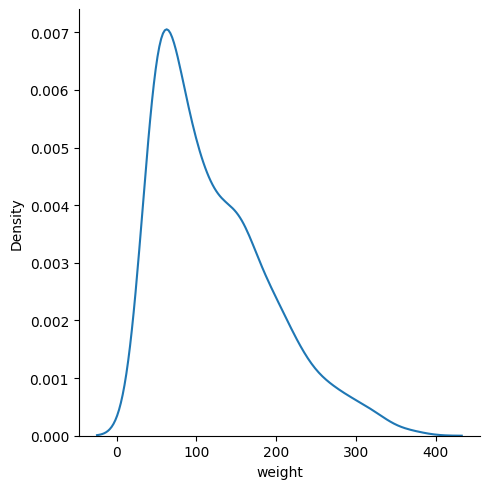

In [34]:
# Plot the distribution of the chickens' weight
sns.displot(data=chicken_data, x='weight', kind="kde")
plt.show()

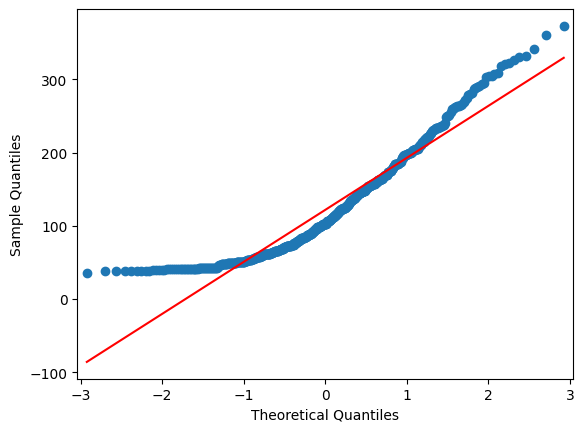

In [32]:
# Plot the qq plot of the chickens' weight
qqplot(data=chicken_data['weight'], line='s')
plt.show()

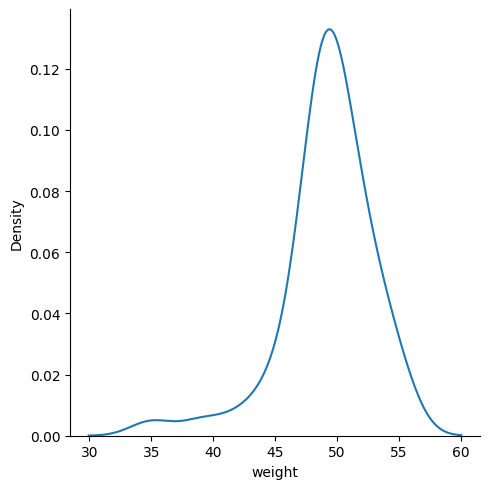

In [33]:
# Subset the data and plot the weight of the subset
subset_data = chicken_data[chicken_data['Time'] == 2]

sns.displot(data=subset_data, x='weight', kind="kde")

plt.show()

# Your first distribution plot looked a bit normal, but the qq plot was not aligned,
# and tapered off at the top and bottom. This indicates the data may have tails that
# affect normality. It also looked a bit more normal at the second time point. Let's confirm some of our thoughts using analytical methods.

**Analytical normality in an agricultural experiment**  
Carrying on from your previous work, your visual inspections of the data indicate it may not be a normal dataset overall, but that the initial time point may be.

Build on your previous work by using analytical methods to determine the normality of the dataset.

The DataFrame chicken_data has been read in for you, and the following package imports have been run already:

    import pandas as pd
    from scipy.stats import shapiro
    from scipy.stats import anderson

- Run a Shapiro-Wilk test of normality on the 'weight' column and print the test statistic and p-value.

In [38]:
# Run a Shapiro-Wilk normality test on the weight column
test_statistic, p_value = shapiro(chicken_data['weight'])

print(f"p: {round(p_value, 4)} test stat: {round(test_statistic, 4)}")

# At a significance level of 0.05, does the Shapiro-Wilk test indicate the data is normally distributed? -> No

p: 0.0 test stat: 0.9087


- Run an Anderson-Darling test for normality and print out the test statistic, significance levels, and critical values from the returned object.

In [41]:
# Run the Anderson-Darling test
result = anderson(chicken_data['weight'], dist="norm")

print(f"Test statistic: {round(result.statistic, 4)}")
print(f"Significance Levels: {result.significance_level}")
print(f"Critical Values: {result.critical_values}")

# Given the returned Anderson-Darling test result, what could you conclude at the 5% significance level? ->
# The data does not come from a Normal distribution.

# The critical value which matches the significance level of 5 is 0.781. When compared
# to the Anderson-Darling test statistic (12.5451), the critical value is much smaller
# and so we reject the null hypothesis and can conclude the data is unlikely to have been drawn from a normal distribution.

Test statistic: 14.6868
Significance Levels: [15.  10.   5.   2.5  1. ]
Critical Values: [0.572 0.652 0.782 0.912 1.085]
